In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/synthetic/player_performance.csv")

X = df[["accuracy", "time_played", "deaths"]]
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
scaled_lr = LogisticRegression(
    max_iter=1000,
    multi_class="auto"
)

scaled_lr.fit(X_train_scaled, y_train)

y_pred_scaled = scaled_lr.predict(X_test_scaled)


In [5]:
print("Accuracy (Scaled LR):", accuracy_score(y_test, y_pred_scaled))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_scaled))


Accuracy (Scaled LR): 0.84

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        66
           1       0.73      0.82      0.77        66
           2       0.92      0.87      0.89        68

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



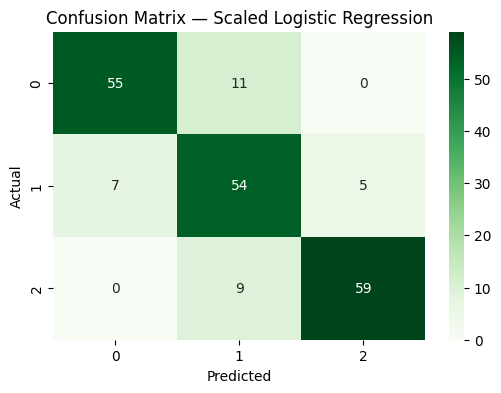

In [6]:
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(6,4))
sns.heatmap(cm_scaled, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Scaled Logistic Regression")
plt.show()


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest training complete.")


Random Forest training complete.


In [8]:
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy (Random Forest): 0.79

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82        66
           1       0.67      0.73      0.70        66
           2       0.87      0.85      0.86        68

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



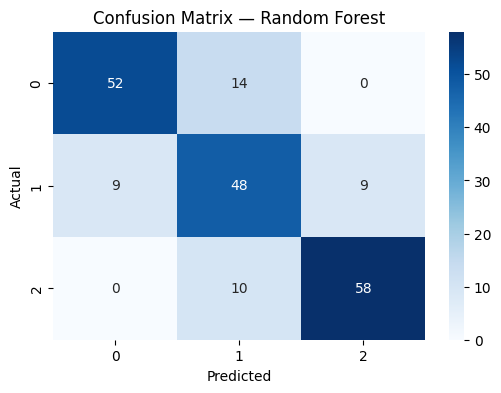

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()


In [10]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


accuracy       0.583525
time_played    0.232692
deaths         0.183783
dtype: float64

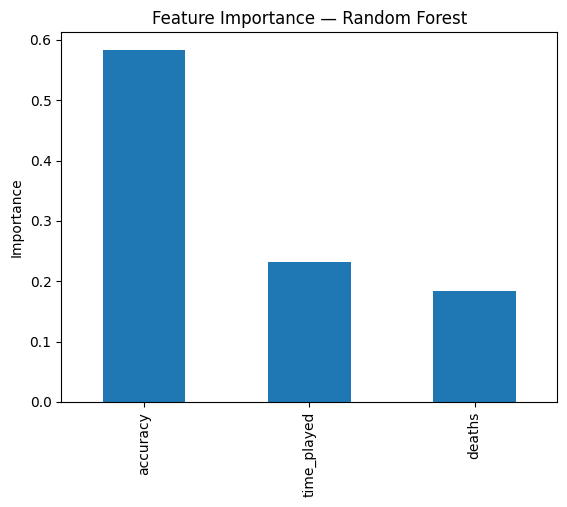

In [11]:
feature_importance.plot(kind='bar')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.show()


In [13]:
# Unscaled Logistic Regression (baseline)
lr_unscaled = LogisticRegression(max_iter=1000)
lr_unscaled.fit(X_train, y_train)

y_pred_unscaled = lr_unscaled.predict(X_test)


In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Unscaled)",
        "Logistic Regression (Scaled)",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_unscaled),
        accuracy_score(y_test, y_pred_scaled),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison


,Model,Accuracy
0,Logistic Regression (Unscaled),0.84
1,Logistic Regression (Scaled),0.84
2,Random Forest,0.79
